## **XGBoost Functions and Hyperparameters**

### **Topic Roadmap**

**1. Create train-validation data**

**2. Inspect core parameters**

**3. Use evaluation history**

**4. Compare a small hyperparameter search**

**5. Key revision notes**

## **1. Dataset and Validation Split**

This notebook focuses on the estimator’s practical controls and diagnostic functions rather than an exhaustive search.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
data = load_breast_cancer(as_frame=True)
X_train, X_temp, y_train, y_temp = train_test_split(
    data.data, data.target, test_size=0.3, stratify=data.target, random_state=RANDOM_STATE
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

## **2. Core Hyperparameters**

The main controls are tree count, learning rate, depth, minimum child weight, row subsampling, and column subsampling.

In [7]:
model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    min_child_weight=2, subsample=0.9, colsample_bytree=0.8,
    reg_alpha=0.0, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1
)
model.get_xgb_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'eval_metric': 'logloss',
 'gamma': None,
 'grow_policy': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': 2,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 1.0,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.9,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

## **3. Evaluation History and Feature Importance**

Passing `eval_set` records validation metrics at each boosting round. `evals_result()` returns the history for plotting or diagnosis.

In [8]:
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_valid, y_valid)], verbose=False)
history = model.evals_result()
print(history.keys())
print(history["validation_1"]["logloss"][-5:])

dict_keys(['validation_0', 'validation_1'])
[0.0362206319860621, 0.0360445223741836, 0.0360485942055033, 0.03579554603750106, 0.03580030834795359]


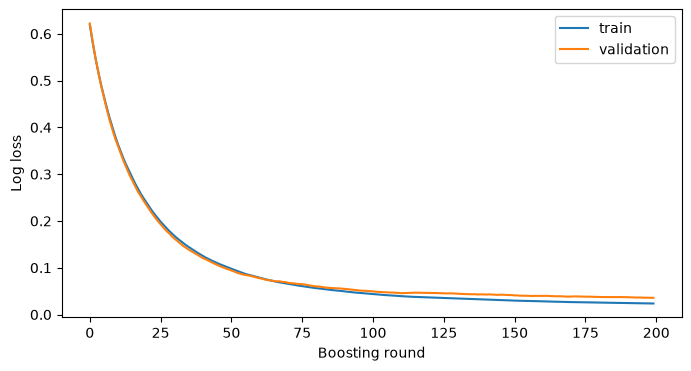

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(history["validation_0"]["logloss"], label="train")
plt.plot(history["validation_1"]["logloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Log loss")
plt.legend()
plt.show()

## **4. Compact Hyperparameter Comparison**

A small manual comparison makes the effect of depth and learning rate transparent without hiding the workflow behind a large search.

In [10]:
experiments = []
for depth in [2, 4]:
    for learning_rate in [0.03, 0.1]:
        candidate = XGBClassifier(
            n_estimators=150, learning_rate=learning_rate, max_depth=depth,
            objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1
        )
        candidate.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        score = accuracy_score(y_valid, candidate.predict(X_valid))
        experiments.append({"max_depth": depth, "learning_rate": learning_rate, "validation_accuracy": score})
pd.DataFrame(experiments).sort_values("validation_accuracy", ascending=False)

,max_depth,learning_rate,validation_accuracy
0,2,0.03,1.000000
1,2,0.10,0.988235
2,4,0.03,0.988235
3,4,0.10,0.988235


### **Key Revision Notes**

- `n_estimators` is the maximum number of boosting rounds.
- `eval_set` and `evals_result()` expose learning curves.
- Depth increases interaction complexity; regularization and subsampling constrain it.
- Keep validation data separate from the final test set.